d:\anacondaaa\lib\site-packages\scipy\__init__.py:155: UserWarning: A NumPy version >=1.18.5 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"




Epoch 1/20


1719/1719 [==============================] - 5s 2ms/step - loss: 0.3355 - rounded_accuracy: 0.8891 - val_loss: 0.3139 - val_rounded_accuracy: 0.9040
Epoch 2/20
1719/1719 [==============================] - 4s 2ms/step - loss: 0.3036 - rounded_accuracy: 0.9171 - val_loss: 0.3006 - val_rounded_accuracy: 0.9202
Epoch 3/20
1719/1719 [==============================] - 4s 2ms/step - loss: 0.2967 - rounded_accuracy: 0.9234 - val_loss: 0.2976 - val_rounded_accuracy: 0.9204
Epoch 4/20
1719/1719 [==============================] - 3s 2ms/step - loss: 0.2921 - rounded_accuracy: 0.9276 - val_loss: 0.2918 - val_rounded_accuracy: 0.9299
Epoch 5/20
1719/1719 [==============================] - 4s 2ms/step - loss: 0.2892 - rounded_accuracy: 0.9302 - val_loss: 0.2895 - val_rounded_accuracy: 0.9316
Epoch 6/20
1719/1719 [==============================] - 4s 2ms/step - loss: 0.2871 - rounded_accuracy: 0.9322 - val_loss: 0.2877 - val_rounded_accuracy: 0.9322
Epoch 7/20
1719/1719 [==============

d:\anacondaaa\lib\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
d:\anacondaaa\lib\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(


Time of execution: 15.77 seconds


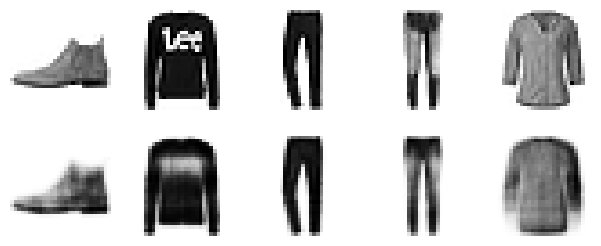

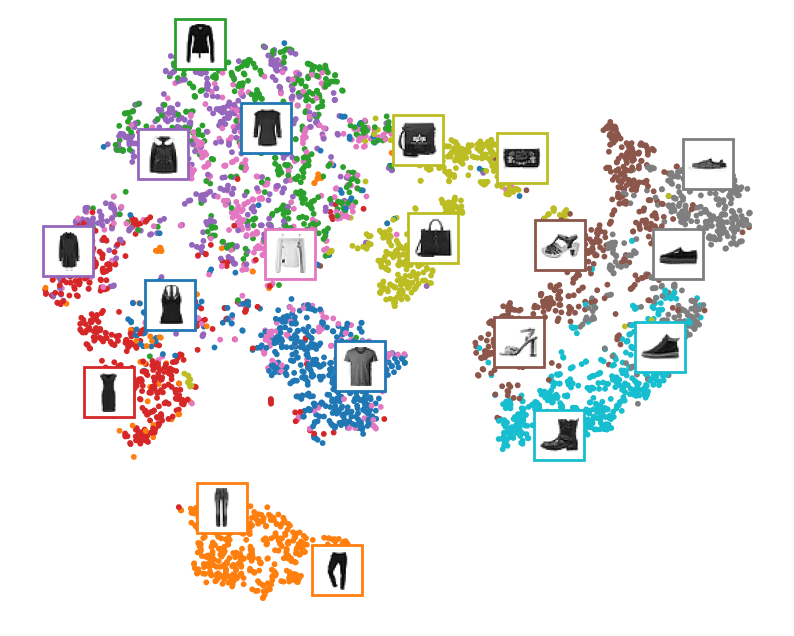

In [1]:
# 导入必要库
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import gzip
import os
import time
from sklearn.manifold import TSNE

# 设置随机种子保证可复现
np.random.seed(42)
tf.random.set_seed(42)

# 绘图配置
%matplotlib inline
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)

# --------------------------
# 核心修改：读取本地MNIST数据集
# --------------------------
def load_mnist(path):
    """
    读取本地MNIST的.gz格式二进制文件
    :param path: 数据集文件所在的文件夹路径（比如"./mnist"）
    :return: (X_train, y_train), (X_test, y_test)
    """
    # 训练集图片
    with gzip.open(os.path.join(path, 'train-images-idx3-ubyte.gz'), 'rb') as f:
        # 跳过前16字节的头部信息
        train_images = np.frombuffer(f.read(), np.uint8, offset=16).reshape(-1, 28, 28)
    # 训练集标签
    with gzip.open(os.path.join(path, 'train-labels-idx1-ubyte.gz'), 'rb') as f:
        # 跳过前8字节的头部信息
        train_labels = np.frombuffer(f.read(), np.uint8, offset=8)
    # 测试集图片
    with gzip.open(os.path.join(path, 't10k-images-idx3-ubyte.gz'), 'rb') as f:
        test_images = np.frombuffer(f.read(), np.uint8, offset=16).reshape(-1, 28, 28)
    # 测试集标签
    with gzip.open(os.path.join(path, 't10k-labels-idx1-ubyte.gz'), 'rb') as f:
        test_labels = np.frombuffer(f.read(), np.uint8, offset=8)
    
    return (train_images, train_labels), (test_images, test_labels)

# --------------------------
# 加载本地数据集（修改这里的路径！）
# --------------------------
# 请把下面的路径改成你存放4个.gz文件的文件夹路径
# 比如文件在当前目录下的"mnist"文件夹里，就写"./mnist"
# 如果文件直接在当前目录，就写"."
(X_train_full, y_train_full), (X_test, y_test) = load_mnist(path=".")

# 数据归一化到0-1
X_train_full = X_train_full / 255.0
X_test = X_test / 255.0

# 划分训练集和验证集
X_train, X_valid = X_train_full[:-5000], X_train_full[-5000:]
y_train, y_valid = y_train_full[:-5000], y_train_full[-5000:]

# --------------------------
# 工具函数（和原来一样）
# --------------------------
def rounded_accuracy(y_true, y_pred):
    return keras.metrics.binary_accuracy(tf.round(y_true), tf.round(y_pred))

def plot_image(image):
    plt.imshow(image, cmap="binary")
    plt.axis("off")

def show_reconstructions(model, images=X_valid, n_images=5):
    reconstructions = model.predict(images[:n_images])
    fig = plt.figure(figsize=(n_images * 1.5, 3))
    for image_index in range(n_images):
        plt.subplot(2, n_images, 1 + image_index)
        plot_image(images[image_index])
        plt.subplot(2, n_images, 1 + n_images + image_index)
        plot_image(reconstructions[image_index])

# --------------------------
# 构建自编码器模型（和原来一样）
# --------------------------
stacked_encoder = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[28, 28]),
    keras.layers.Dense(100, activation="selu"),
    keras.layers.Dense(30, activation="selu"),
])

stacked_decoder = keras.models.Sequential([
    keras.layers.Dense(100, activation="selu", input_shape=[30]),
    keras.layers.Dense(28 * 28, activation="sigmoid"),
    keras.layers.Reshape([28, 28])
])

stacked_ae = keras.models.Sequential([stacked_encoder, stacked_decoder])

stacked_ae.compile(
    loss="binary_crossentropy",
    optimizer=keras.optimizers.SGD(learning_rate=1.5), 
    metrics=[rounded_accuracy]
)

# --------------------------
# 训练模型（和原来一样）
# --------------------------
start = time.time()

history = stacked_ae.fit(
    X_train, X_train, 
    epochs=20,
    validation_data=(X_valid, X_valid)
)

end = time.time()
print("Time of execution:", round(end - start, 2), "seconds")

# --------------------------
# 评估与可视化（和原来一样）
# --------------------------
# 重建效果可视化
show_reconstructions(stacked_ae, X_test)

# 模型评估
stacked_ae.evaluate(X_test, X_test)

# t-SNE降维可视化
np.random.seed(42)

start = time.time()

X_valid_compressed = stacked_encoder.predict(X_valid)
tsne = TSNE()
X_valid_2D = tsne.fit_transform(X_valid_compressed)
X_valid_2D = (X_valid_2D - X_valid_2D.min()) / (X_valid_2D.max() - X_valid_2D.min())

end = time.time()
print("Time of execution:", round(end - start, 2), "seconds")

plt.figure(figsize=(10, 8))
cmap = plt.cm.tab10
plt.scatter(X_valid_2D[:, 0], X_valid_2D[:, 1], c=y_valid, s=10, cmap=cmap)
image_positions = np.array([[1., 1.]])
for index, position in enumerate(X_valid_2D):
    dist = np.sum((position - image_positions) ** 2, axis=1)
    if np.min(dist) > 0.02:  # 避免图片重叠
        image_positions = np.r_[image_positions, [position]]
        imagebox = mpl.offsetbox.AnnotationBbox(
            mpl.offsetbox.OffsetImage(X_valid[index], cmap="binary"),
            position, 
            bboxprops={"edgecolor": cmap(y_valid[index]), "lw": 2}
        )
        plt.gca().add_artist(imagebox)
plt.axis("off")
plt.show()